# Decision Tree

A decision tree is a supervised machine learning algorithm that splits data into subsets based on conditional "if-then" rules to make predictions. It uses a flowchart-like, upside-down tree structure composed of a root node (starting question), internal nodes (subsequent tests), branches (outcomes), and leaf nodes (final classification or numeric prediction)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import tree
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [ ]:
df = pd.read_csv(r"C:\Users\deves\Documents\GitHub\Free_Datasets\Data Sets\titanic.csv")
df = df.rename(columns={i:i.lower() for i in df.columns})
df.head()

In [ ]:
df.info()

In [ ]:
df.describe().round(2)

In [ ]:
df.isnull().sum()

In [ ]:
# keep usefull columns
print(df.columns)

In [ ]:
df = df.drop(columns=['passengerid','name','ticket'])

In [ ]:
df.head()

In [ ]:
# clean age columns
df['age'].describe()

In [ ]:
df['age'] = df['age'].fillna(df['age'].median())

In [ ]:
# clean cabin
df.cabin

In [ ]:
df['cabin'] = df.cabin.notnull()

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
# clean embarked
df.embarked.value_counts()

In [ ]:
df['embarked'] = df.embarked.fillna("S")

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
# rename columns in all lower

x = df.drop(columns="survived")
y = df['survived']

In [ ]:
# Train test split
xtrain, xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
xtrain

In [ ]:
ytrain

In [ ]:
xtest

In [ ]:
ytest

In [ ]:
# Decision Trees do not require feature scaling.
# Decision Trees do need encoding if your dataset contains categorical (text) features.
# you need to remove null values only

Index(['sex', 'embarked'], dtype='object')

In [46]:
encoder = OneHotEncoder()
cat = df.select_dtypes("object").columns
transformer = ColumnTransformer(
    [
        ("cat",encoder,cat)
    ]
)


In [47]:
model = DecisionTreeClassifier()
pipe = Pipeline([
    ("encode",transformer),
    ("model",model)
])

In [48]:
pipe.fit(xtrain,ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('encode', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['pclass','sex','age',...,'fare','cabin','embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified 

In [50]:
prediction = pipe.predict(xtest)

In [52]:
# accuracy on training data
accuracy_score(ytest,prediction)

0.7821229050279329

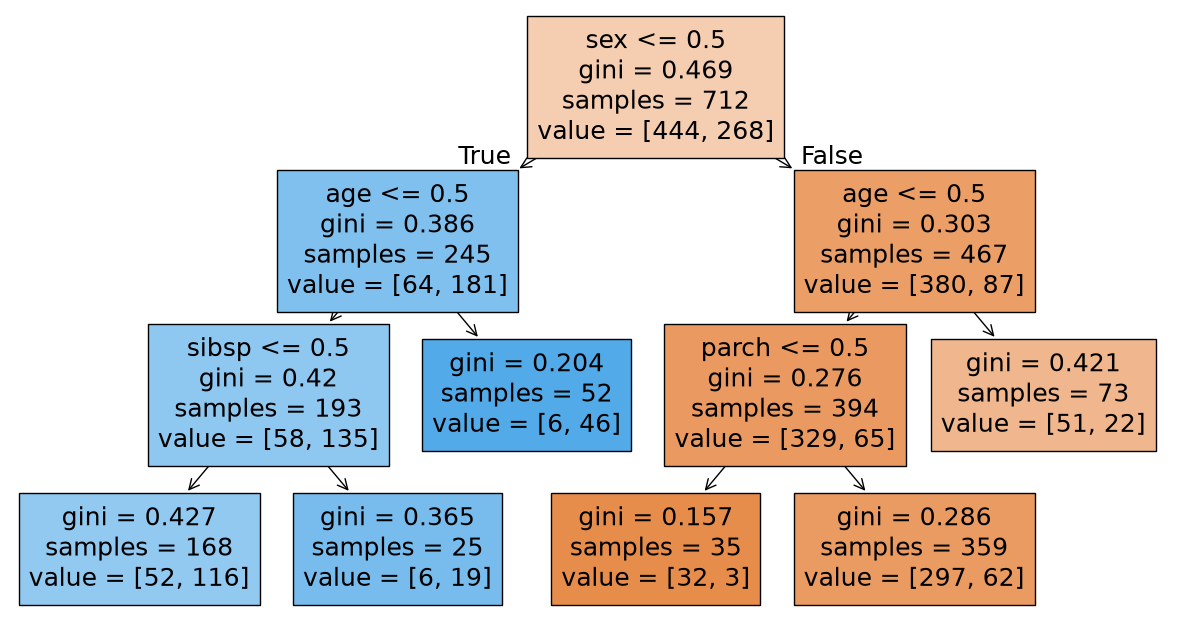

In [56]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
plot_tree(
    model,
    feature_names=xtrain.columns,
    filled=True
)
plt.show()